In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

df_games = pd.read_csv("C:/Users/esteb/Documents/Esteban/CURSOS/Data-analisis-ComIT_ok/proyecto-final-data-analysis/data/steam_games_clean.csv")
df_reviews = pd.read_csv("C:/Users/esteb/Documents/Esteban/CURSOS/Data-analisis-ComIT_ok/proyecto-final-data-analysis/data/steam_games_reviews.csv")

In [5]:
df_games.estimated_owners.value_counts()

estimated_owners
20000 - 50000            11258
50000 - 100000            5290
100000 - 200000           3402
200000 - 500000           2801
500000 - 1000000          1124
1000000 - 2000000          704
2000000 - 5000000          393
5000000 - 10000000         119
10000000 - 20000000         49
20000000 - 50000000         29
50000000 - 100000000         7
100000000 - 200000000        4
Name: count, dtype: int64

In [2]:
#Se hace una copia del DB para ajustar la óptica de los registros más relevantes para el análisis de los juegos más exitosos. Se tomarán los registros con mas de 1.000.000 ventas, significando aproximadamente la mitad de la escala de la que se tienen registros.

df_games2 = df_games.copy()

df_games2["estimated_owners"] = df_games2.estimated_owners[df_games2.estimated_owners.isin(["1000000 - 2000000", "2000000 - 5000000", "5000000 - 10000000", "10000000 - 20000000", "20000000 - 50000000", "50000000 - 100000000", "100000000 - 200000000"])]

df_games2 = df_games2.dropna(subset=["estimated_owners"])

df_games2.head()

,app_id,name,release_date,price,price_status,estimated_owners,developers,publishers,genres,categories,tags,positive,negative,average_playtime_forever,median_playtime_forever,short_description,dlc_count,new_app_id
26,879160,Battlerite Royale,2019-02-19,0.00,free,1000000 - 2000000,"[""Stunlock Studios""]","[""Stunlock Studios""]","[""Action"", ""Free To Play"", ""Massively Multipla...","[""Single-player"", ""Multi-player"", ""PvP"", ""Onli...","[""Battle Royale"", ""Free to Play"", ""Multiplayer...",6088,2103,529,115,Explore the fantastical Talon Island in a thri...,3,27
38,880940,Pummel Party,2018-09-20,14.99,paid,2000000 - 5000000,"[""Rebuilt Games""]","[""Rebuilt Games""]","[""Action"", ""Casual"", ""Indie""]","[""Single-player"", ""Multi-player"", ""PvP"", ""Onli...","[""Multiplayer"", ""Funny"", ""Online Co-Op"", ""4 Pl...",47800,6014,872,429,Pummel Party is a 4-8 player online and local-...,0,39
40,881020,Granblue Fantasy: Relink,2024-01-31,59.99,paid,2000000 - 5000000,"[""Cygames, Inc.""]","[""Cygames, Inc.""]","[""Action"", ""Adventure"", ""RPG""]","[""Single-player"", ""Multi-player"", ""Co-op"", ""On...","[""Anime"", ""JRPG"", ""Action RPG"", ""Action"", ""Onl...",43116,4883,3506,1788,A grand adventure in the skies awaits! Form a ...,25,41
41,881100,Noita,2020-10-15,19.99,paid,2000000 - 5000000,"[""Nolla Games""]","[""Nolla Games""]","[""Action"", ""Adventure"", ""Indie"", ""RPG"", ""Simul...","[""Single-player"", ""Steam Achievements"", ""Steam...","[""Physics"", ""Rogue-like"", ""Pixel Graphics"", ""D...",74759,3718,2075,350,Noita is a magical action roguelite set in a w...,1,42
52,882100,XCOM®: Chimera Squad,2020-04-23,9.99,paid,1000000 - 2000000,"[""Firaxis Games""]","[""2K""]","[""Strategy""]","[""Single-player"", ""Steam Achievements"", ""Steam...","[""Strategy"", ""Turn-Based Tactics"", ""Turn-Based...",16302,6407,1095,608,XCOM: Chimera Squad delivers an all-new story ...,0,53


In [9]:
#Creación de columnas de total rating y porcentaje positivo de reseñas.

df_games2["total_ratings"] = df_games2["positive"] + df_games2["negative"]

df_games2["good_rating"] = (((df_games2["positive"] - df_games2["negative"]) / df_games2["total_ratings"]) * 100).round(2)

In [10]:
#Catalogación por numero de ventas.

best_sellers = df_games2[df_games2.estimated_owners.isin(["10000000 - 20000000", "20000000 - 50000000", "50000000 - 100000000", "100000000 - 200000000", "50000000 - 100000000"])]

top_best_seller1 = df_games2[df_games2.estimated_owners == "100000000 - 200000000"]

top_best_seller2 = df_games2[df_games2.estimated_owners == "50000000 - 100000000"]



In [56]:
#Filtrado de los juegos más vendidos en relación al balance de puntuaciones de usuarios.

loved_best_sellers = best_sellers[best_sellers.good_rating >= 90].sort_values(by="good_rating", ascending=False)

new_loved_best_sellers = loved_best_sellers[loved_best_sellers.release_date > "2021-01-01"]




In [ ]:
#Normalización de datos de la comlumna Tags. Actualmente tiene por cada tag asignado un numero. Se eliminan los caracteres que no nos interesan y separamos los términos clave con str.split.
#df_games2["tags"] = df_games1["tags"].str.replace("0", "").str.replace("1", "").str.replace("2", "").str.replace("3", "").str.replace("4", "").str.replace("5", "").str.replace("6", "").str.replace("7", "").str.replace("8", "").str.replace("9", "").str.replace(":", "")

#df_games2["categories"] = df_games1["categories"].str.replace("0", "").str.replace("1", "").str.replace("2", "").str.replace("3", "").str.replace("4", "").str.replace("5", "").str.replace("6", "").str.replace("7", "").str.replace("8", "").str.replace("9", "")

#df_games2["genres"] = df_games1["genres"].str.replace("0", "").str.replace("1", "").str.replace("2", "").str.replace("3", "").str.replace("4", "").str.replace("5", "").str.replace("6", "").str.replace("7", "").str.replace("8", "").str.replace("9", "")



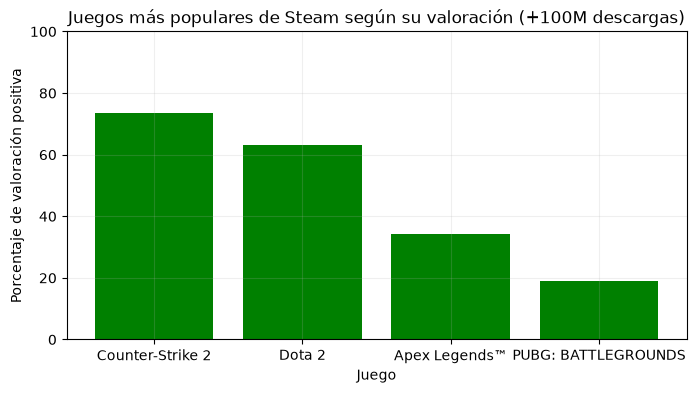

In [61]:
#Visualización juegos más populares segun su valoración positiva. ¿Qué juegos son los más populares historicamente?
top_best_seller1 = top_best_seller1.sort_values(by="good_rating", ascending=False)

fig, ax = plt.subplots(figsize = (8,4))
ax.bar(top_best_seller1.name, top_best_seller1.good_rating, color="green")
ax.set_title("Juegos más populares de Steam según su valoración (+100M descargas)")
ax.set_xlabel("Juego")
ax.set_ylabel("Porcentaje de valoración positiva")
ax.set_ylim(0, 100)
ax.grid(alpha=0.2)
plt.show()

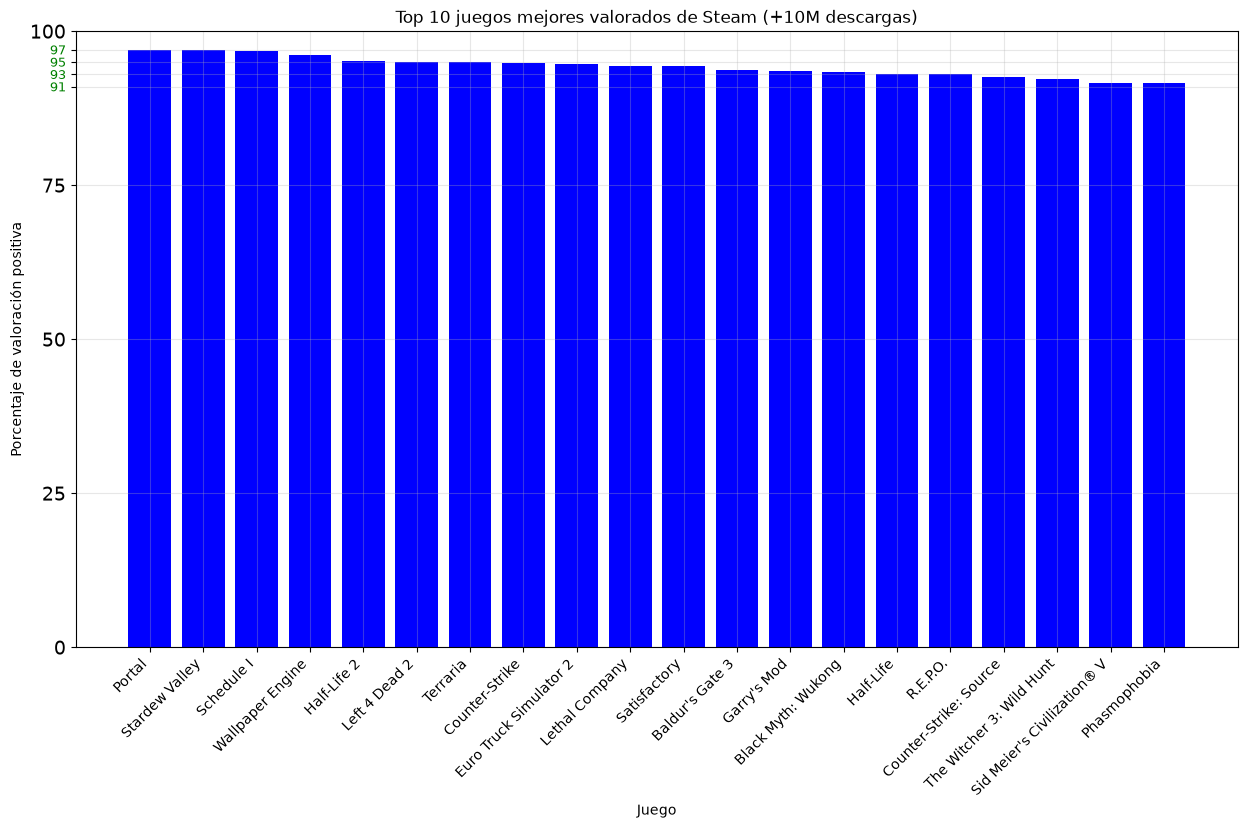

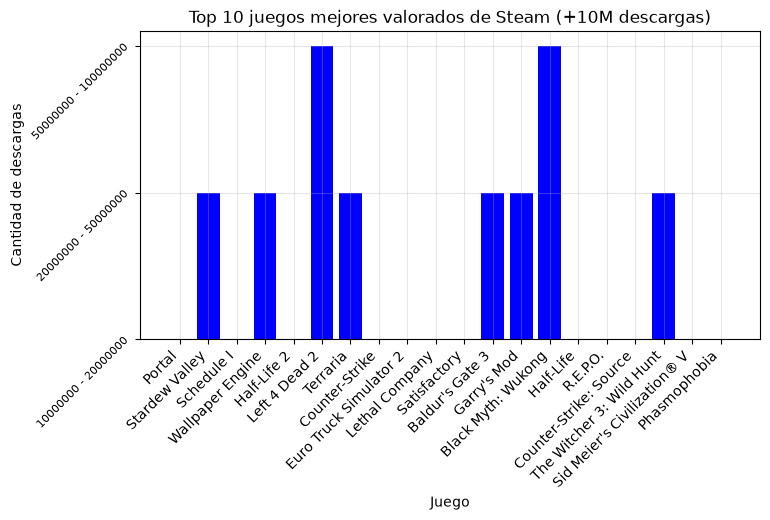

In [62]:
#Visualización juegos mejores valorados con más de 10M descargas según valoración. ¿Que juegos son los más gustados históricamentes?
loved_best_sellers_grph = loved_best_sellers.sort_values(by="good_rating", ascending=False).head(20)

fig, ax = plt.subplots(figsize = (15,8))
ax.bar(loved_best_sellers_grph.name, loved_best_sellers_grph.good_rating, color="blue")
ax.set_title("Top 10 juegos mejores valorados de Steam (+10M descargas)")
ax.set_xlabel("Juego")
ax.set_ylabel("Porcentaje de valoración positiva")
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)

ax.set_yticks([0,25,50,75,91, 93, 95, 97, 100])
plt.xticks(rotation=45, ha="right")

for label in ax.get_yticklabels():
    if label.get_text() >= "90":
        label.set_fontsize(9)
        label.set_color("green")
    else:
        label.set_fontsize(14)

plt.show()

#Visualización juegos mejores valorados con más de 10M descargas según descargas.

fig, ax = plt.subplots(figsize = (8,4))
ax.bar(loved_best_sellers_grph.name, loved_best_sellers_grph.estimated_owners, color="blue")
ax.set_title("Top 10 juegos mejores valorados de Steam (+10M descargas)")
ax.set_xlabel("Juego")
ax.set_ylabel("Cantidad de descargas")
ax.grid(alpha=0.3)


plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=45, ha="right", fontsize=8)


plt.show()


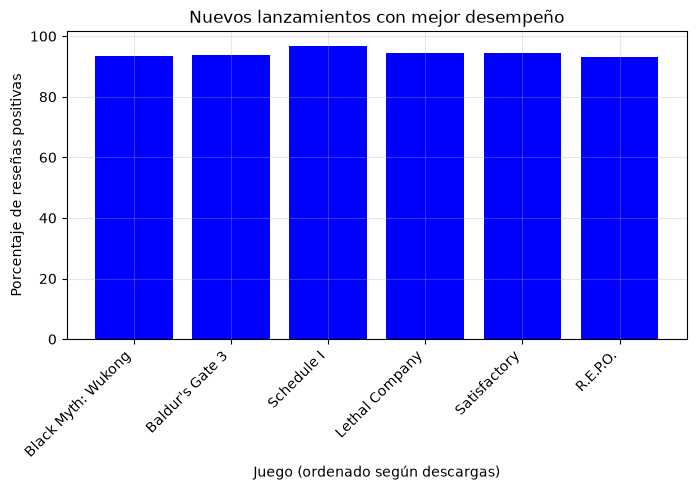

11151    2024-08-19
1876     2023-08-03
13197    2025-03-24
9299     2023-10-23
16793    2024-09-10
13321    2025-02-26
Name: release_date, dtype: str


In [63]:
#Visualización de juegos nuevos, lanzados a partir de 2022 que alcanzaron el exito en ventas y buenas puntuaciones. ¿Que juegos recientes tuvieron éxito en el mercado actual?

new_loved_best_sellers_grph = new_loved_best_sellers.sort_values(by="estimated_owners", ascending=False)

fig, ax = plt.subplots(figsize = (8,4))
ax.bar(new_loved_best_sellers_grph.name, new_loved_best_sellers_grph.good_rating, color="blue")
ax.set_title("Nuevos lanzamientos con mejor desempeño")
ax.set_xlabel("Juego (ordenado según descargas)")
ax.set_ylabel("Porcentaje de reseñas positivas")
ax.grid(alpha=0.3)


plt.xticks(rotation=45, ha="right")

plt.show()

print(new_loved_best_sellers_grph.release_date)

In [64]:
#Me falta stacked bars para comparativa negative vs positive en top 10 históricos. Asi se ve en contexto cuantas reseñas hay por cada uno.

#Analizar tags y genres de juegos + populares(que da masividad), mejores valorados históricos(que funciona historicamente) y nuevos lanzamientos(que funciona ahora).